using SGD optimiser as baseline on cifar10 

In [1]:
# we are building our model using sigmoid
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from tensorflow.keras.utils import plot_model
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm


In [2]:
#We use random seed value while creating training and test data set.
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()

170508288/170498071 [==============================] - 11s 0us/step


In [3]:
# we are splitting the data into training and testing 
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0


In [4]:
#np_utils. to_categorical is used to convert array of labeled data(from 0 to nb_classes - 1 ) 
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [5]:
#we are creating our model
def define_model():
  # we are creating the first input layer and hidden layer for CNN
 model = Sequential()
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization()) 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Flatten()) # we are using flatten layer for converting it into one dimensional array
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())


 model.add(Dense(class_num))
 model.add(Activation('sigmoid'))
  

 opt = SGD(lr=0.01, momentum=0.9)
 # we are copiling the model
 model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
 return model

/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


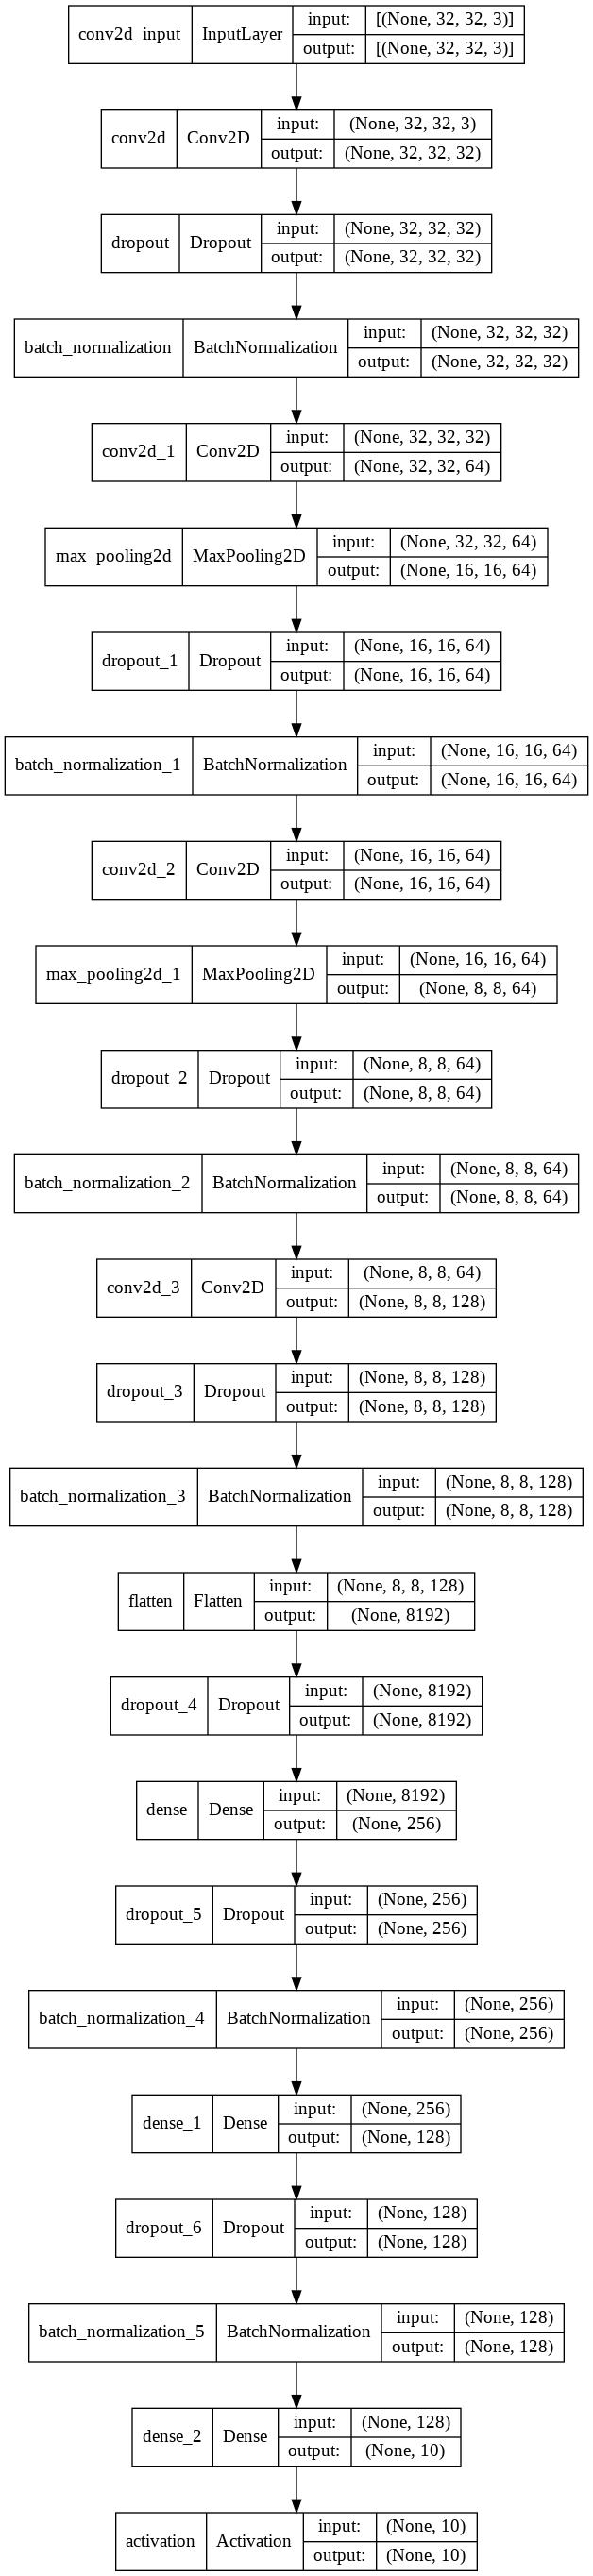

In [6]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating our model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 

Epoch 1/5
391/391 [==============================] - 360s 918ms/step - loss: 1.6565 - accuracy: 0.4057 - val_loss: 1.9701 - val_accuracy: 0.3232
Epoch 2/5
391/391 [==============================] - 359s 917ms/step - loss: 1.3147 - accuracy: 0.5231 - val_loss: 1.5142 - val_accuracy: 0.4881
Epoch 3/5
391/391 [==============================] - 360s 921ms/step - loss: 1.1435 - accuracy: 0.5908 - val_loss: 1.0126 - val_accuracy: 0.6410
Epoch 4/5
391/391 [==============================] - 360s 919ms/step - loss: 1.0084 - accuracy: 0.6400 - val_loss: 1.1354 - val_accuracy: 0.6045
Epoch 5/5
391/391 [==============================] - 369s 943ms/step - loss: 0.9090 - accuracy: 0.6786 - val_loss: 0.8617 - val_accuracy: 0.6946


we got accuracy = 0.6786 and loss = 0.9090 with epochs = 5 batch size=128

we got cnn error 30.54%

In [ ]:
# the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 30.54%


In [7]:
# we are building the model 
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from tensorflow.keras.utils import plot_model
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm


In [8]:
#We use random seed value while creating training and test data set.
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()

In [9]:
# we are splitting the data into training and testing
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0


In [10]:
# we are feature scaling here into 0 and 1
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [11]:
#we are creating the model
def define_model():
  # we are creating the first input lyer and hidden layer for CNN
 model = Sequential()
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization()) 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Flatten()) # we are using flatten layer for converting it into one dimensional array
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())


 model.add(Dense(class_num))
 model.add(Activation('elu'))
  

 opt = SGD(lr=0.01, momentum=0.9)
 # we are copiling the model
 model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
 return model

/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


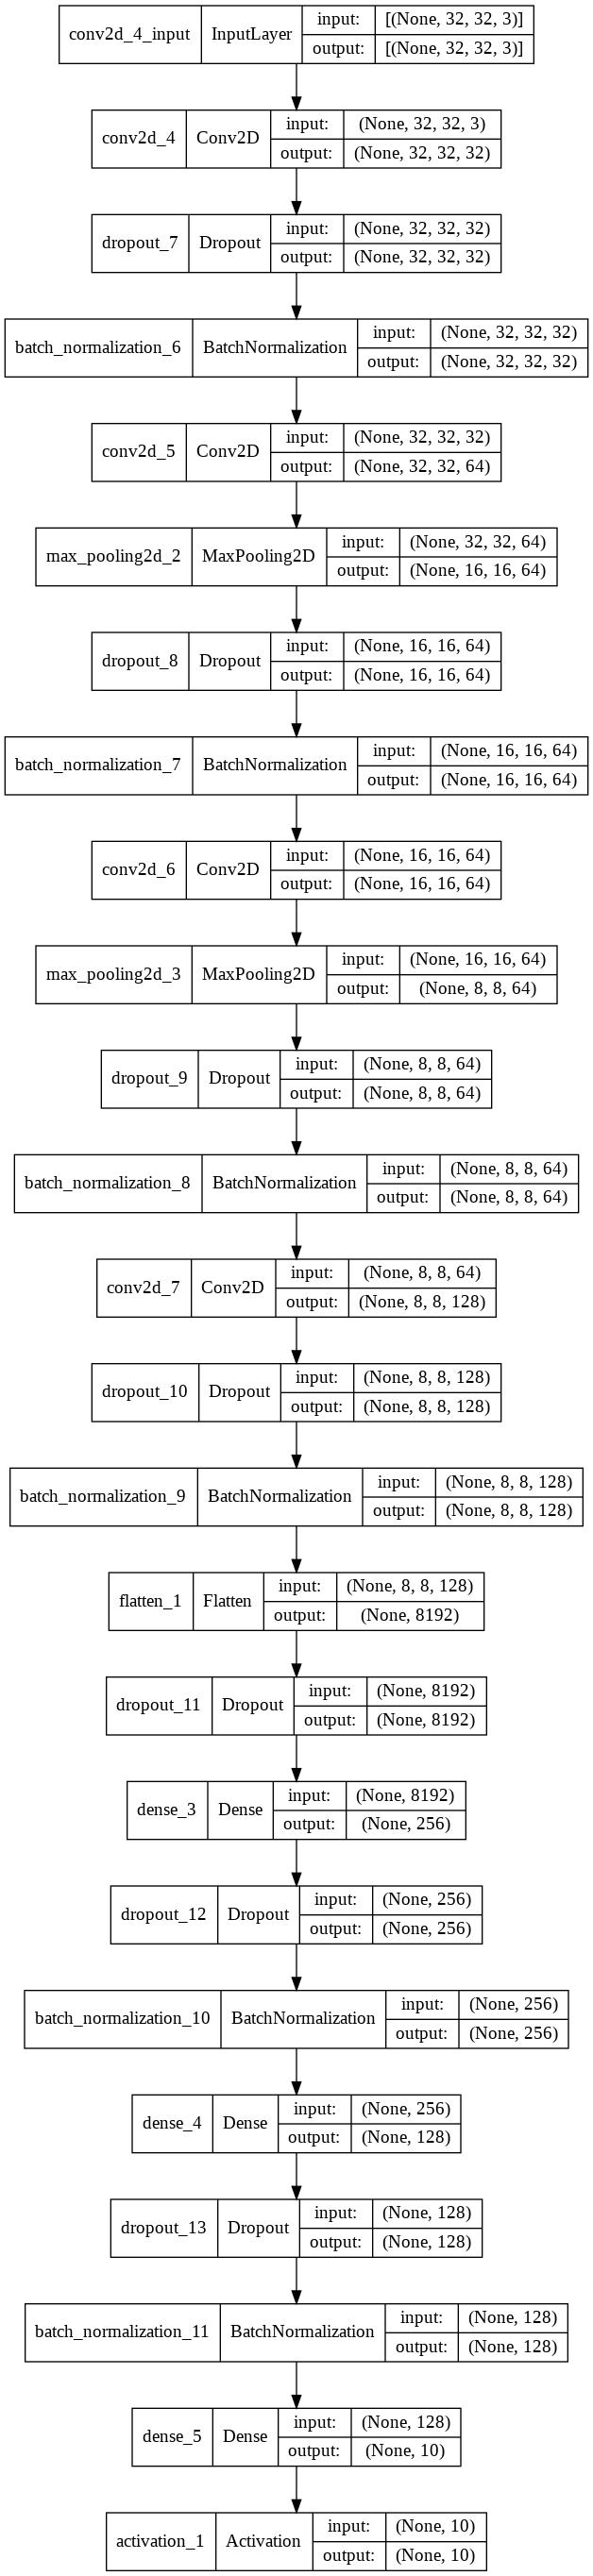

In [12]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 



Epoch 1/5
391/391 [==============================] - 417s 1s/step - loss: 3.7877 - accuracy: 0.1204 - val_loss: 2.8850 - val_accuracy: 0.1223
Epoch 2/5
391/391 [==============================] - 404s 1s/step - loss: 2.9309 - accuracy: 0.1277 - val_loss: 2.6153 - val_accuracy: 0.1271
Epoch 3/5
391/391 [==============================] - 357s 914ms/step - loss: 2.7542 - accuracy: 0.1369 - val_loss: 2.5565 - val_accuracy: 0.1305
Epoch 4/5
391/391 [==============================] - 358s 915ms/step - loss: 2.6801 - accuracy: 0.1436 - val_loss: 3.2116 - val_accuracy: 0.1156
Epoch 5/5
391/391 [==============================] - 359s 918ms/step - loss: 2.7339 - accuracy: 0.1254 - val_loss: 2.5131 - val_accuracy: 0.1095


we take epochs = 5 batch size = 128 got accuracy = 0.1254 and 
loss = 2.7339

In [13]:
# we are building the model
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import plot_model
from keras.layers import BatchNormalization
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm


In [14]:
#We use random seed value while creating training and test data set. 
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()


In [15]:
# we are splitting the data into training and testing 
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0


In [16]:
# we are feature scaling here from 0 to 1
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [17]:
#we are creating the model
def define_model():
  # we are creating the first layer and hidden layer of the model
 model = Sequential()
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization()) 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#  we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Flatten()) # we are using flatten layer for converting it into one dimensional array
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())


 model.add(Dense(class_num))
 model.add(Activation('selu'))
  

 opt = SGD(lr=0.01, momentum=0.9)
 # we are compiling the model
 model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
 return model

/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


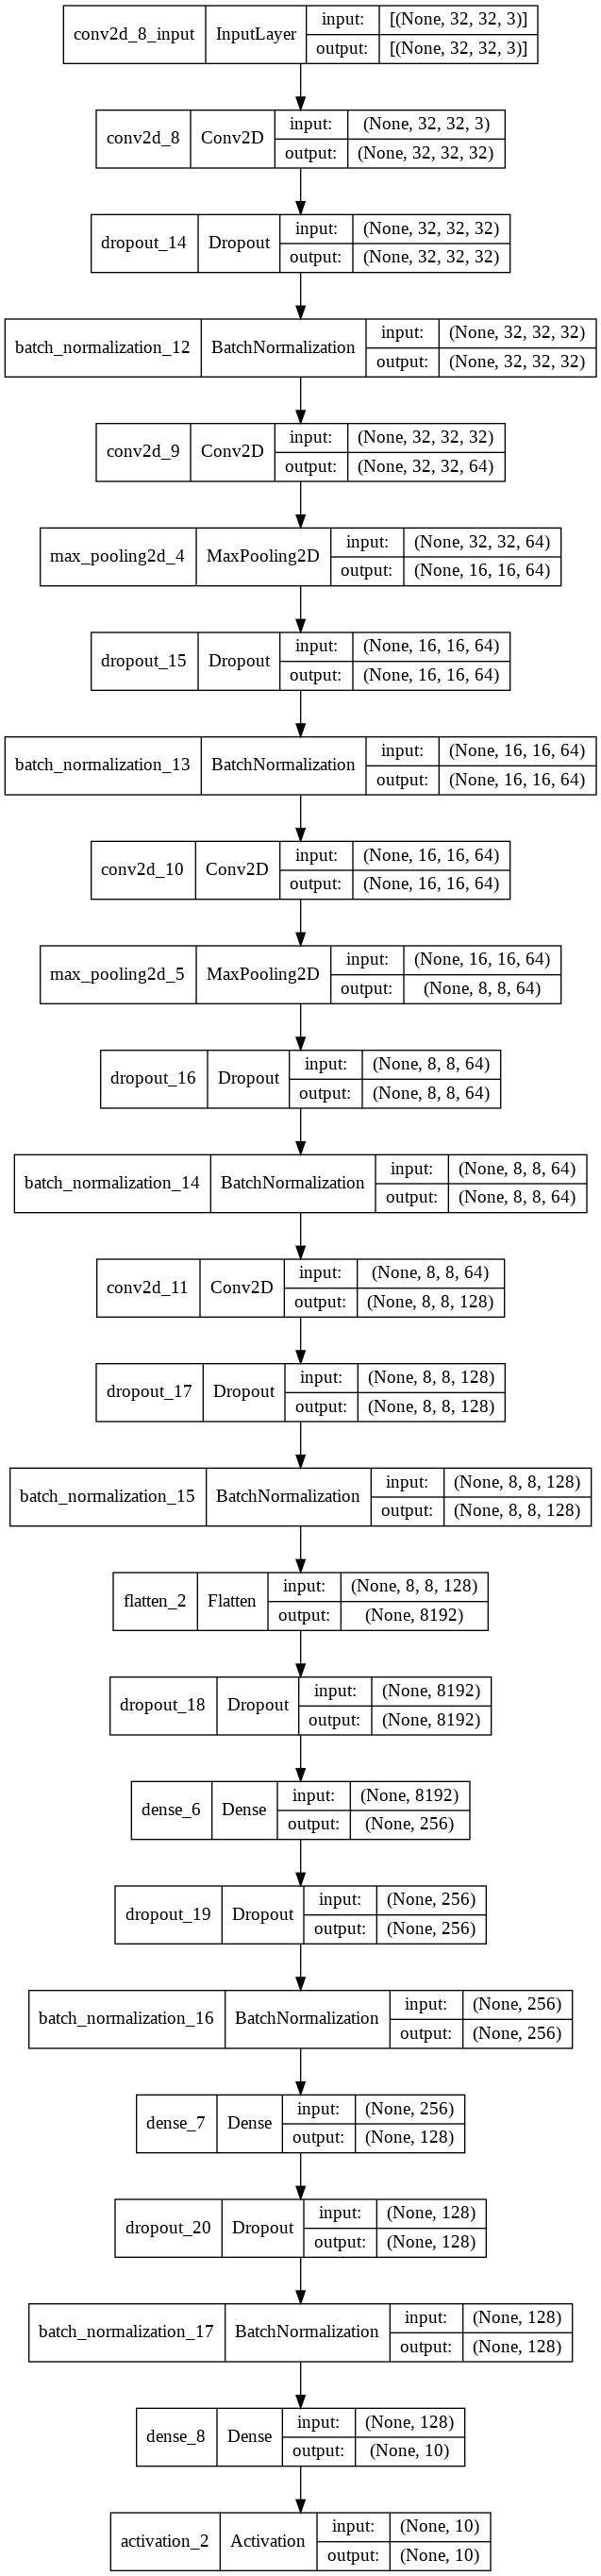

In [18]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 



Epoch 1/5
391/391 [==============================] - 357s 910ms/step - loss: 4.5560 - accuracy: 0.1241 - val_loss: 3.0234 - val_accuracy: 0.1605
Epoch 2/5
391/391 [==============================] - 396s 1s/step - loss: 3.1272 - accuracy: 0.1399 - val_loss: 3.2136 - val_accuracy: 0.1623
Epoch 3/5
391/391 [==============================] - 354s 906ms/step - loss: 2.9499 - accuracy: 0.1508 - val_loss: 2.8625 - val_accuracy: 0.1698
Epoch 4/5
391/391 [==============================] - 354s 904ms/step - loss: 2.8672 - accuracy: 0.1472 - val_loss: 2.7794 - val_accuracy: 0.1605
Epoch 5/5
391/391 [==============================] - 352s 901ms/step - loss: 2.7890 - accuracy: 0.1484 - val_loss: 2.7490 - val_accuracy: 0.1458


we take epochs = 5 and batch size = 128 and got the accuracy of 
0.1484 and loss = 2.7890

we got cnn error as 85.42%

In [ ]:
# the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))


CNN Error: 85.42%


In [19]:
# we are building the model
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from tensorflow.keras.utils import plot_model
from keras.layers import Dropout
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm

In [20]:
#We use random seed value while creating training and test data set. 
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()


In [21]:
# we are splitting the data into training and testing
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0

In [22]:
# we are converting the values in between 0 and 1 
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]


In [23]:
#we are creating the model
def define_model():
  # we are creating the first input layer of the model and hidden layer
 model = Sequential()
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization()) 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Flatten()) # we are using flatten layer for converting it into one dimensional array
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())


 model.add(Dense(class_num))
 model.add(Activation('relu'))
  

 opt = SGD(lr=0.01, momentum=0.9)
 # we are compiling the modle
 model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
 return model


/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


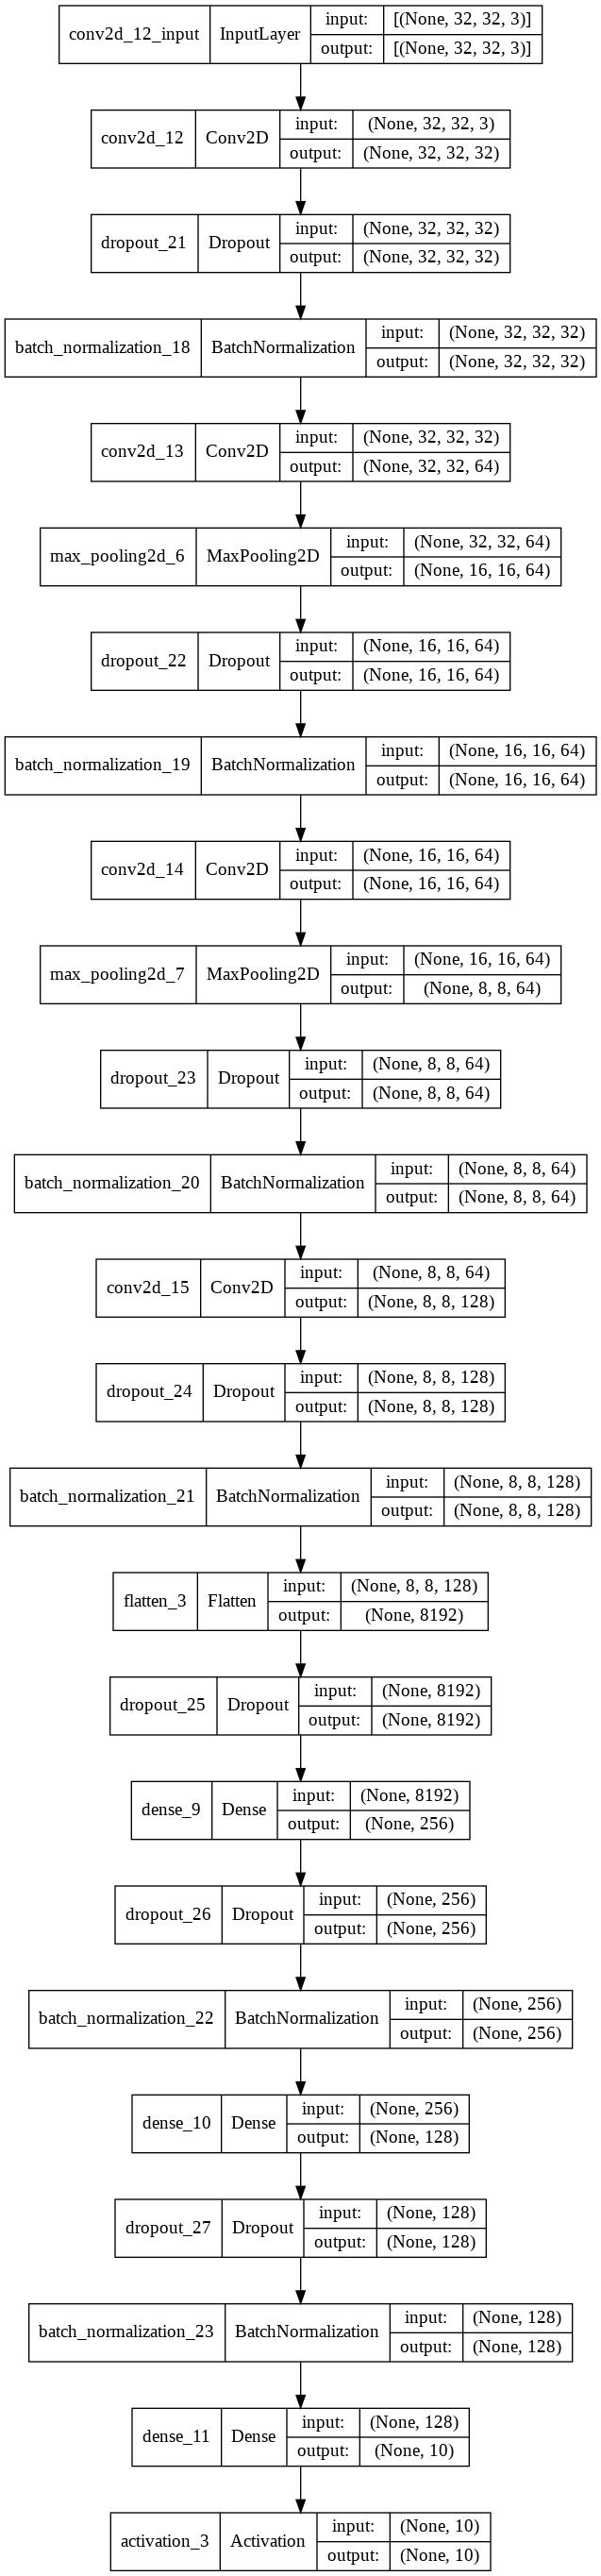

In [24]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 


Epoch 1/5
391/391 [==============================] - 348s 886ms/step - loss: nan - accuracy: 0.1014 - val_loss: nan - val_accuracy: 0.1000
Epoch 2/5
391/391 [==============================] - 347s 888ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000
Epoch 3/5
391/391 [==============================] - 346s 886ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000
Epoch 4/5
391/391 [==============================] - 346s 885ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000
Epoch 5/5
391/391 [==============================] - 347s 889ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000


we take 5 epochs and 128 batch size and got the accuracy of 0.1000
loss = nan

90.00% we got cnn erro 

In [ ]:
# the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 90.00%


In [25]:
#we are building the model with tanh
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from tensorflow.keras.utils import plot_model
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm


In [26]:
#We use random seed value while creating training and test data set. 
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()

In [27]:
# we are splitting the data into training and testing
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0


In [28]:
# we are performing feature scaling for better accuracy
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [29]:
#we are creating the model
def define_model():
  # we are creating first input layer and hidden layer for CNN
 model = Sequential()
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization()) 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Flatten()) # we are using flatten layer for converting it into one dimensional array
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))
 model.add(BatchNormalization())


 model.add(Dense(class_num))
 model.add(Activation('tanh'))
  

 opt = SGD(lr=0.01, momentum=0.9)
 # we are compiling the model
 model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
 return model

/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


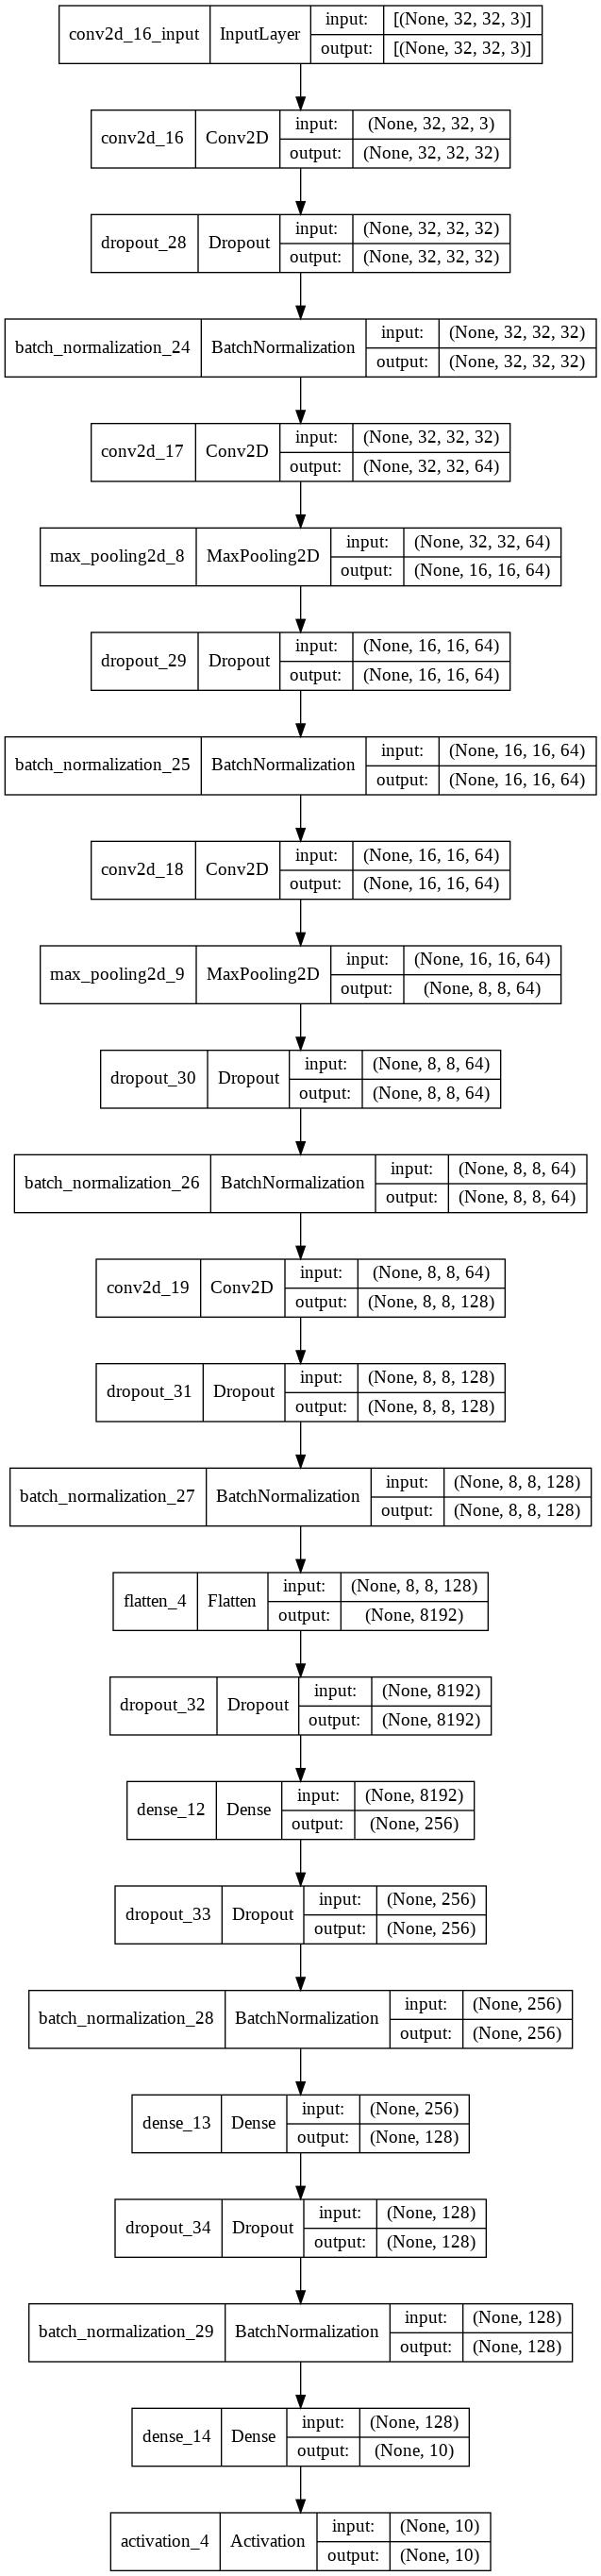

In [30]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model


In [ ]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 

Epoch 1/5
391/391 [==============================] - 355s 906ms/step - loss: 4.7633 - accuracy: 0.1125 - val_loss: 2.3642 - val_accuracy: 0.0991
Epoch 2/5
391/391 [==============================] - 349s 893ms/step - loss: nan - accuracy: 0.0947 - val_loss: nan - val_accuracy: 0.1000
Epoch 3/5
391/391 [==============================] - 345s 883ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000
Epoch 4/5
391/391 [==============================] - 345s 882ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000
Epoch 5/5
391/391 [==============================] - 346s 886ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000


we take epochs = 5 and batch size = 128 and got the accuracy 0.1000
 loss = nan

we got cnn error as 90.00%

In [ ]:
# the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 90.00%


Using ADAGRAD RMSProp and Adam optimizer

In [31]:
# we are building the model using adam optimizer
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm


In [32]:
#We use random seed value while creating training and test data set. 
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()

In [33]:
# we are splitting our data into training and testing
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0

In [34]:
# we are fature scaling for better accuracy
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [35]:
#we are creating our model
def define_model():
  # we are creating our first input layer and hidden layer for CNN
 model = Sequential()
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization()) 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Flatten()) # we are using flatten layer for converting it into one dimensional array
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())


 model.add(Dense(class_num))
 model.add(Activation('sigmoid'))
  
# we are compiling the model
 model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 return model

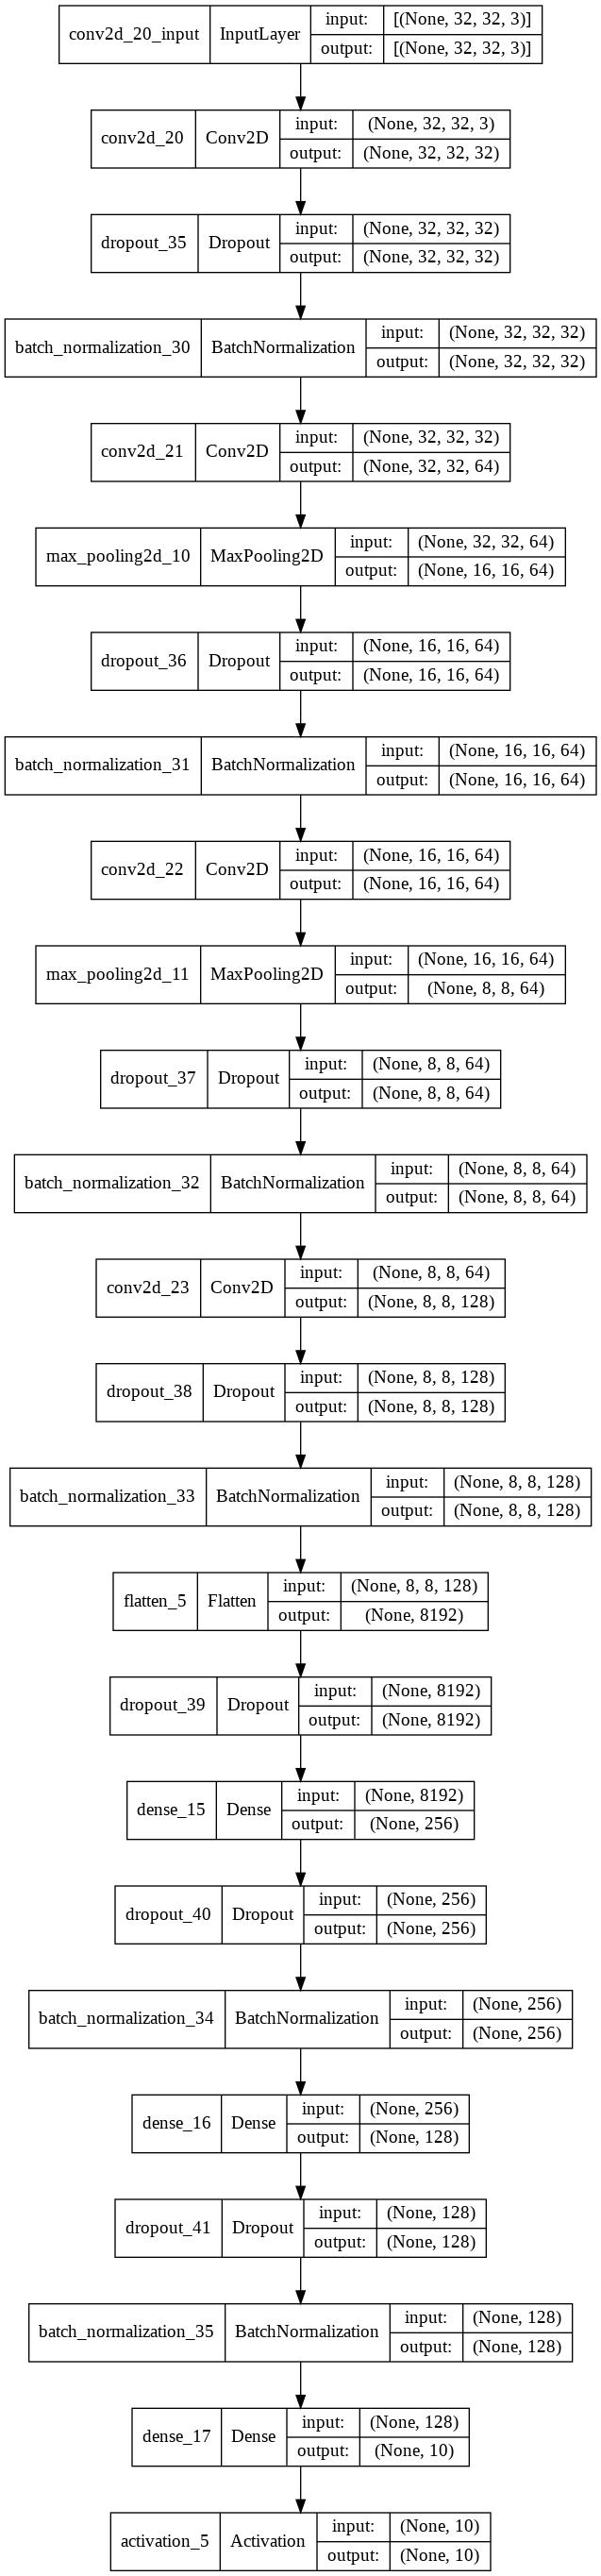

In [36]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are testing and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 

Epoch 1/5
391/391 [==============================] - 391s 997ms/step - loss: 1.5346 - accuracy: 0.4553 - val_loss: 4.0331 - val_accuracy: 0.2014
Epoch 2/5
391/391 [==============================] - 357s 913ms/step - loss: 1.0490 - accuracy: 0.6272 - val_loss: 1.0364 - val_accuracy: 0.6412
Epoch 3/5
391/391 [==============================] - 359s 919ms/step - loss: 0.8628 - accuracy: 0.6948 - val_loss: 0.8165 - val_accuracy: 0.7204
Epoch 4/5
391/391 [==============================] - 354s 904ms/step - loss: 0.7553 - accuracy: 0.7346 - val_loss: 0.7113 - val_accuracy: 0.7515
Epoch 5/5
391/391 [==============================] - 354s 906ms/step - loss: 0.6759 - accuracy: 0.7619 - val_loss: 0.6732 - val_accuracy: 0.7659


we take epochs = 5 and batch size = 128 accuracy = 0.7619 and 
loss = 0.6759

we got cnn error as 23.41%

In [ ]:
# the final representation of CNN error  
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))


CNN Error: 23.41%


In [37]:
# Using sigmoid adagrad we afre building the model
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from tensorflow.keras.utils import plot_model
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from tensorflow.keras.optimizers import SGD
from keras.layers import BatchNormalization
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm


In [38]:
# The “seed” is a starting point for the sequence and the guarantee is that if you start from the same seed you will get the same sequence of numbers.
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()


In [39]:
# we are splitting the data into training and testing
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0

In [40]:
#  Using the method to_categorical(), a numpy array (or) a vector which has integers that represent different categories, 
#can be converted into a numpy array (or) a matrix which has binary values and has columns equal to the number of categories in the data.
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [41]:
# we are creating our model 
def define_model():
  # we are creating our first input layer and hidden layer
 model = Sequential()
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 # we are creating batch normalization and pooling layer
 model.add(BatchNormalization())
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization()) 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))
 model.add(BatchNormalization())
 # we are flattening the layer
 model.add(Flatten()) # we are using flatten layer for converting it into one dimensional array
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3)))# dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())


 model.add(Dense(class_num))
 model.add(Activation('sigmoid'))
  

# we are compiling the model
 model.compile(optimizer='adagrad', loss='categorical_crossentropy', metrics=['accuracy'])
 return model


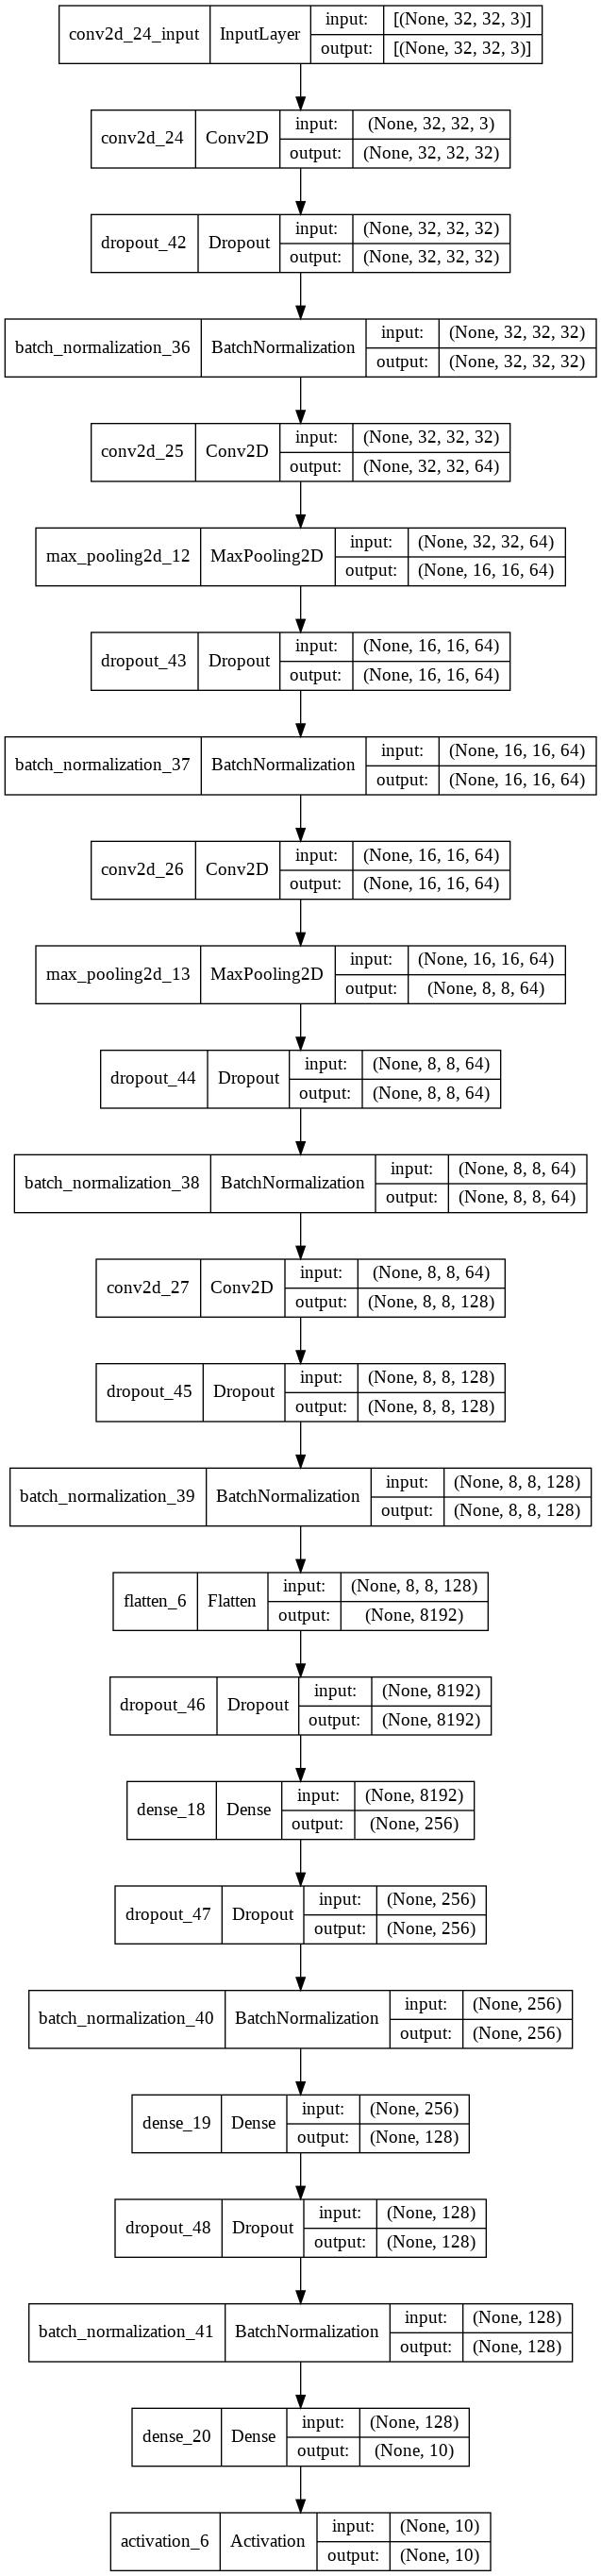

In [42]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 



Epoch 1/5
391/391 [==============================] - 411s 1s/step - loss: 2.3512 - accuracy: 0.2244 - val_loss: 3.3795 - val_accuracy: 0.1003
Epoch 2/5
391/391 [==============================] - 410s 1s/step - loss: 2.0063 - accuracy: 0.3096 - val_loss: 2.5849 - val_accuracy: 0.1499
Epoch 3/5
391/391 [==============================] - 415s 1s/step - loss: 1.8820 - accuracy: 0.3440 - val_loss: 2.3002 - val_accuracy: 0.2115
Epoch 4/5
391/391 [==============================] - 423s 1s/step - loss: 1.7973 - accuracy: 0.3676 - val_loss: 2.2403 - val_accuracy: 0.2308
Epoch 5/5
391/391 [==============================] - 420s 1s/step - loss: 1.7383 - accuracy: 0.3851 - val_loss: 2.1512 - val_accuracy: 0.2579


we take epochs = 5 and batch size = 128 and got the accuracy of 0.3851 and 
loss = 1.7383


we got cnn error as 74.21%

In [ ]:
# the final representation of model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 74.21%


In [43]:
# using RMS prop for building the model
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import plot_model
from keras.layers import BatchNormalization
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm


In [44]:
#The “seed” is a starting point for the sequence and the guarantee is that if you start from the same seed you will get the same sequence of numbers.
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()

In [45]:
# we are splitting the data into traininga and testing 
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0

In [46]:
#Using the method to_categorical(), a numpy array (or) a vector which has integers that represent different 
#categories, can be converted into a numpy array (or) a matrix which has binary values and has columns equal to the number of categories in the data.
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]


In [47]:
# we are creating the model 
def define_model():
  # we are creating our model as sequential
 model = Sequential()
 # we are creating the first input layer and hidden layer
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))) # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2)) # we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization()) 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it to the array of smaller size
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a covolutional operator for filtering windows of two dimensional input
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())
 model.add(Flatten()) # we are using flatten layer for converting it into one dimensional array
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))#we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regurlarly deeply connected neural network layers
 model.add(Dropout(0.2))# we are using the dropout function for reducing the weights in order to reduce the overfitting
 model.add(BatchNormalization())


 model.add(Dense(class_num))
 model.add(Activation('sigmoid'))
  
# we are compiling the model
 model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
 return model

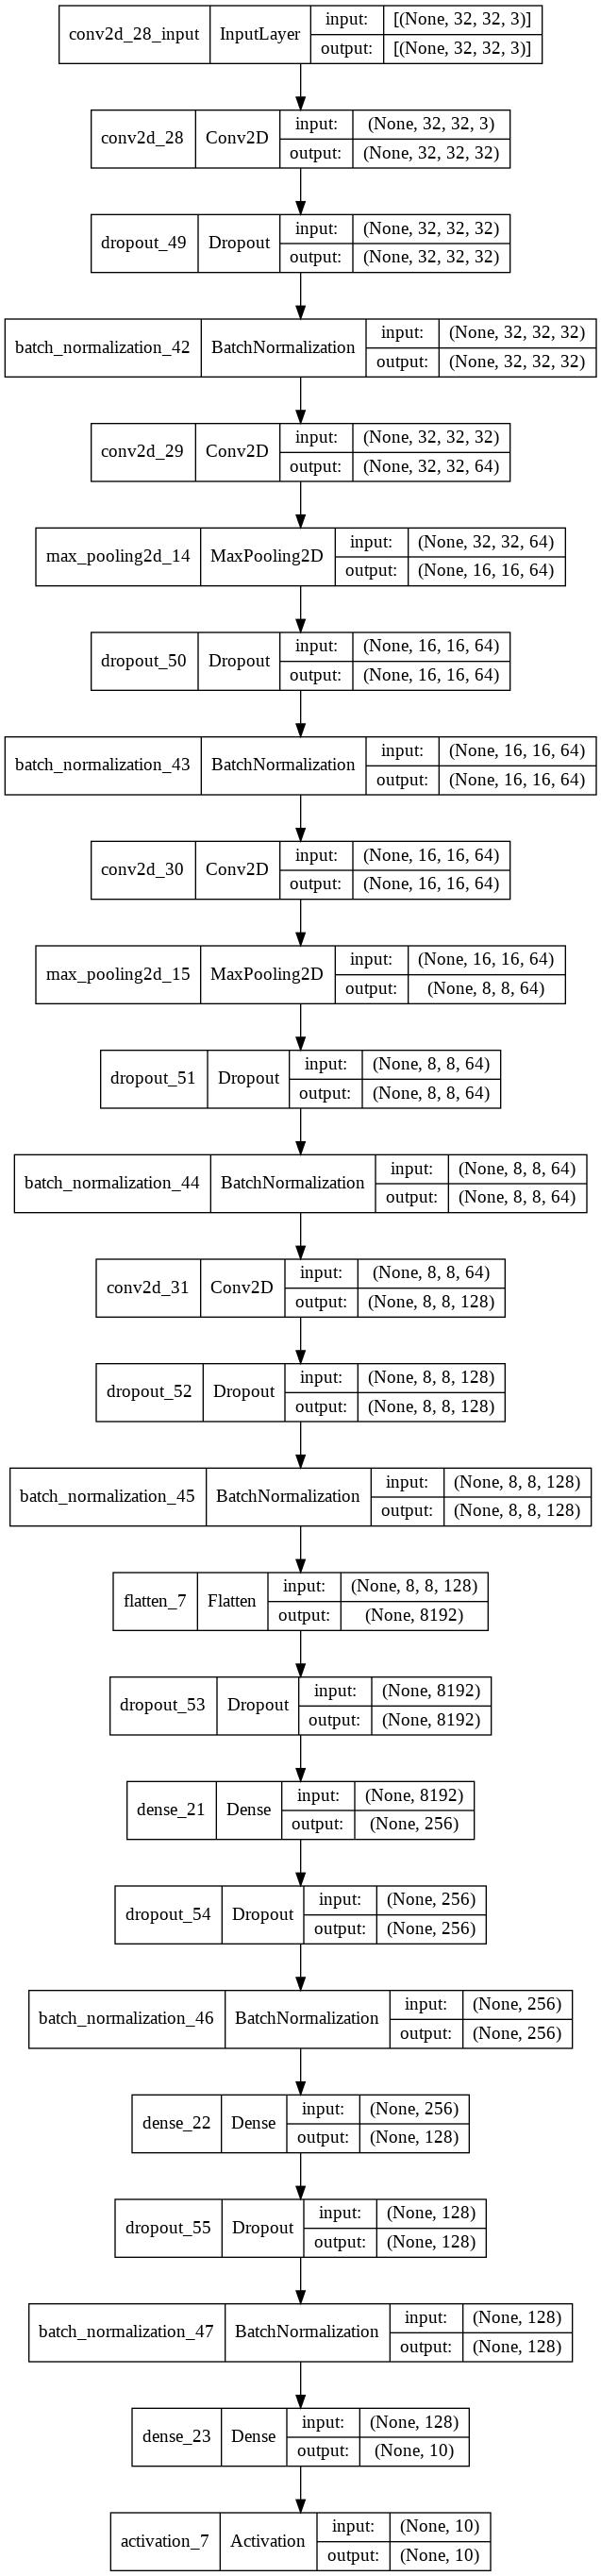

In [48]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 

Epoch 1/5
391/391 [==============================] - 470s 1s/step - loss: 1.4822 - accuracy: 0.4757 - val_loss: 3.1322 - val_accuracy: 0.2114
Epoch 2/5
391/391 [==============================] - 448s 1s/step - loss: 0.9806 - accuracy: 0.6530 - val_loss: 0.8639 - val_accuracy: 0.6964
Epoch 3/5
391/391 [==============================] - 455s 1s/step - loss: 0.8148 - accuracy: 0.7123 - val_loss: 0.8668 - val_accuracy: 0.7009
Epoch 4/5
391/391 [==============================] - 459s 1s/step - loss: 0.7202 - accuracy: 0.7491 - val_loss: 0.6653 - val_accuracy: 0.7696
Epoch 5/5
391/391 [==============================] - 479s 1s/step - loss: 0.6430 - accuracy: 0.7748 - val_loss: 0.7841 - val_accuracy: 0.7318


we took epochs = 5 and batch size = 128 and got the accuracy of 0.7748 
and loss = 0.6430

we got CNN error as 26.82%

In [ ]:
# the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 26.82%
